# WindSight: US Wind Fleet Analysis

This notebook contains the analysis behind the WindSight US Wind Market Entry Strategy project. It uses the cleaned US wind turbine dataset together with EIA 923 data to examine fleet age, changes in turbine rated capacity, and operators associated with older wind assets.

The analysis uses 2022 as the reference year for fleet age because the turbine inventory represents a January 2022 snapshot. Turbines are counted at the individual turbine level using `turbine_id`, while rated capacity and electricity generation are treated as separate measures.

The results in this notebook are intended as a historical market screening exercise. They do not represent current turbine condition, legal ownership, realized energy yield, reliability, or investment return.


## 1. Setup and analytical definitions


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

AS_OF_YEAR = 2022
AGING_THRESHOLD = 20
CAPACITY_COMPARE_YEARS = [2011, 2021]

# Works both in the repository and in the original working folder.
SEARCH_DIRS = [Path("."), Path("data"), Path("../data"), Path("/mnt/data")]

def locate_file(filename):
    for folder in SEARCH_DIRS:
        path = folder / filename
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename}. Checked: {SEARCH_DIRS}")

WIND_FILE = locate_file("Wind_Turbine_Cleaned.csv")
EIA_FILE = locate_file("EIA923_2020_Wind_Cleaned.csv")

print("Wind file:", WIND_FILE)
print("EIA file: ", EIA_FILE)
print(f"Age definition: {AS_OF_YEAR} - project_year")
print(f"Aging threshold: {AGING_THRESHOLD}+ years")

Wind file: Wind_Turbine_Cleaned.csv
EIA file:  EIA923_2020_Wind_Cleaned.csv
Age definition: 2022 - project_year
Aging threshold: 20+ years


## 2. Load the cleaned datasets

The wind turbine file is used as the main asset level dataset. EIA 923 is used to identify reported operators and to retain generation data for separate analysis.


In [2]:
wind = pd.read_csv(WIND_FILE)
eia = pd.read_csv(EIA_FILE)

print(f"Wind turbine rows: {len(wind):,}")
print(f"EIA-923 rows:      {len(eia):,}")
display(wind.head())
display(eia.head())

Wind turbine rows: 70,808
EIA-923 rows:      1,242


,turbine_id,plant_id,state,county,project_name,project_year,turbine_manufacturer,turbine_model,turbine_capacity_kw,is_retrofitted,retrofit_year,longitude,latitude
0,3072661,"52,161.00",CA,Kern County,251 Wind,"1,987.00",Vestas,NaN,95.00,0,NaN,-118.36,35.08
1,3072695,"52,161.00",CA,Kern County,251 Wind,"1,987.00",Vestas,NaN,95.00,0,NaN,-118.36,35.08
2,3072704,"52,161.00",CA,Kern County,251 Wind,"1,987.00",Vestas,NaN,95.00,0,NaN,-118.36,35.08
3,3063272,NaN,IA,Story County,30 MW Iowa DG Portfolio,"2,017.00",Nordex,AW125/3000,"3,000.00",0,NaN,-93.43,42.03
4,3053390,NaN,IA,Boone County,30 MW Iowa DG Portfolio,"2,017.00",Nordex,AW125/3000,"3,000.00",0,NaN,-93.70,41.98


,Plant Id,Plant Name,Operator Id,Operator Name,Plant State,NERC Region,Balancing Authority Code,Reported Fuel Type Code,Reported Prime Mover,Netgen January,Netgen February,Netgen March,Netgen April,Netgen May,Netgen June,Netgen July,Netgen August,Netgen September,Netgen October,Netgen November,Netgen December,Net Generation (Megawatthours)
0,1,Sand Point,63560,"TDX Sand Point Generating, LLC",AK,Unknown,Unknown,WND,WT,30.32,31.08,31.13,30.98,29.43,31.20,23.00,23.32,23.56,28.98,33.30,30.69,347.00
1,90,Snake River,13642,Nome Joint Utility Systems,AK,Unknown,Unknown,WND,WT,208.20,213.41,213.80,212.77,202.12,214.28,157.96,160.18,161.79,199.03,228.66,210.79,"2,383.00"
2,508,Lamar Plant,10633,City of Lamar - (CO),CO,WECC,PSCO,WND,WT,"1,367.38","1,098.84",991.48,970.00,"1,368.07","1,011.49","1,097.18","1,042.13",901.63,952.68,"1,092.82","1,338.32","13,232.00"
3,692,Medicine Bow,62042,SRIV Partnership LLC,WY,WECC,WAUW,WND,WT,"2,015.12","1,747.22","1,325.98","1,127.26","1,026.19","1,071.78",942.31,786.86,765.21,"1,313.84","1,936.10","2,063.12","16,121.00"
4,944,Geneseo,7095,City of Geneseo - (IL),IL,MRO,MISO,WND,WT,490.00,433.00,698.00,691.00,468.00,306.00,216.00,190.00,420.00,540.00,855.00,548.00,"5,855.00"


## 3. Data quality checks

Before starting the analysis, I checked the fields used in the calculations and confirmed the turbine level grain of the main dataset. Rated capacity is treated as installed nameplate capacity rather than actual electricity output.


In [3]:
required_wind = {
    "turbine_id", "plant_id", "state", "project_name", "project_year",
    "turbine_capacity_kw", "longitude", "latitude"
}
required_eia = {"Plant Id", "Operator Name", "Net Generation (Megawatthours)"}

assert required_wind.issubset(wind.columns), required_wind - set(wind.columns)
assert required_eia.issubset(eia.columns), required_eia - set(eia.columns)
assert wind["turbine_id"].is_unique, "turbine_id is not unique: turbine grain is violated."

quality = pd.DataFrame({
    "metric": [
        "Turbine rows", "Unique turbine IDs", "Missing project year",
        "Missing rated capacity", "Missing plant ID", "Earliest project year", "Latest project year"
    ],
    "value": [
        len(wind), wind["turbine_id"].nunique(), wind["project_year"].isna().sum(),
        wind["turbine_capacity_kw"].isna().sum(), wind["plant_id"].isna().sum(),
        int(wind["project_year"].min()), int(wind["project_year"].max())
    ]
})
display(quality)

assert int(wind["project_year"].max()) == 2021, "Recheck the capacity comparison: dataset coverage has changed."
print("✓ Turbine grain validated.")
print("✓ Published turbine data ends in 2021; no 2024 result will be claimed from this file.")

,metric,value
0,Turbine rows,70808
1,Unique turbine IDs,70808
2,Missing project year,613
3,Missing rated capacity,5480
4,Missing plant ID,5793
5,Earliest project year,1981
6,Latest project year,2021


✓ Turbine grain validated.
✓ Published turbine data ends in 2021; no 2024 result will be claimed from this file.


## 4. Fleet age

Turbine age is calculated consistently as `2022 minus project_year`.

Only turbines with a recorded project year are included in the age calculation. This keeps missing commissioning years from being assigned to an age group.


In [4]:
wind = wind.copy()
wind["turbine_age"] = AS_OF_YEAR - wind["project_year"]

valid_age = wind.loc[wind["project_year"].notna()].copy()
aging = valid_age.loc[valid_age["turbine_age"] >= AGING_THRESHOLD].copy()

age_summary = pd.DataFrame({
    "metric": [
        "All turbine records",
        "Turbines with valid project year",
        f"Turbines aged {AGING_THRESHOLD}+ as of {AS_OF_YEAR}",
        f"Share aged {AGING_THRESHOLD}+",
        "Median turbine age",
        "Oldest observed turbine age"
    ],
    "value": [
        f"{wind['turbine_id'].nunique():,}",
        f"{valid_age['turbine_id'].nunique():,}",
        f"{aging['turbine_id'].nunique():,}",
        f"{aging['turbine_id'].nunique()/valid_age['turbine_id'].nunique()*100:.2f}%",
        f"{valid_age['turbine_age'].median():.0f} years",
        f"{valid_age['turbine_age'].max():.0f} years"
    ]
})
display(age_summary)

assert valid_age["turbine_id"].nunique() == 70195
assert aging["turbine_id"].nunique() == 6252
print("✓ Reproduced: 6,252 of 70,195 turbines with a valid year are 20+ years old (8.91%).")

,metric,value
0,All turbine records,"70,808"
1,Turbines with valid project year,"70,195"
2,Turbines aged 20+ as of 2022,"6,252"
3,Share aged 20+,8.91%
4,Median turbine age,10 years
5,Oldest observed turbine age,41 years


✓ Reproduced: 6,252 of 70,195 turbines with a valid year are 20+ years old (8.91%).


### Age distribution

The following table shows the number of projects represented at each turbine age using the same 2022 reference year throughout the analysis.


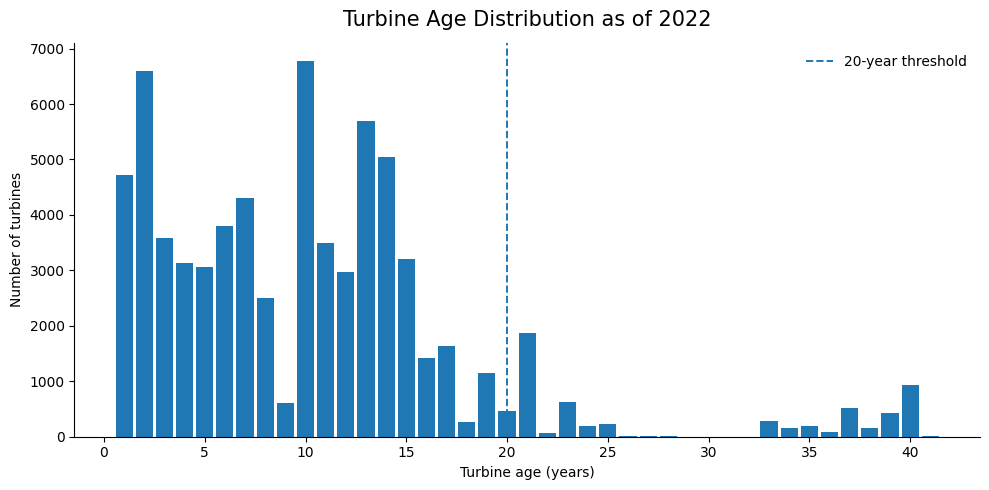

In [5]:
age_counts = (
    valid_age.groupby("turbine_age", as_index=False)
    .agg(turbines=("turbine_id", "nunique"))
    .sort_values("turbine_age")
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(age_counts["turbine_age"], age_counts["turbines"], width=0.85)
ax.axvline(AGING_THRESHOLD, linestyle="--", linewidth=1.4, label=f"{AGING_THRESHOLD}-year threshold")
ax.set_title(f"Turbine Age Distribution as of {AS_OF_YEAR}", fontsize=15, pad=12)
ax.set_xlabel("Turbine age (years)")
ax.set_ylabel("Number of turbines")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### Age groups

The age groups are used to describe the fleet for screening purposes. They should not be interpreted as an assessment of turbine condition or remaining useful life.


In [6]:
bins = [-np.inf, 9, 19, 30, np.inf]
labels = ["0–9 years", "10–19 years", "20–30 years", "31+ years"]
valid_age["age_band"] = pd.cut(valid_age["turbine_age"], bins=bins, labels=labels)

age_bands = (
    valid_age.groupby("age_band", observed=False)
    .agg(turbines=("turbine_id", "nunique"), rated_capacity_mw=("turbine_capacity_kw", lambda s: s.sum(min_count=1)/1000))
    .reset_index()
)
age_bands["share_of_valid_age_turbines_pct"] = age_bands["turbines"] / valid_age["turbine_id"].nunique() * 100
display(age_bands)

,age_band,turbines,rated_capacity_mw,share_of_valid_age_turbines_pct
0,0–9 years,32292,"69,947.65",46.00
1,10–19 years,31651,"55,476.53",45.09
2,20–30 years,3484,"2,737.31",4.96
3,31+ years,2768,110.41,3.94


### Share of the fleet aged 20 or more

This view isolates the 20-year threshold used throughout the analysis and shows its share of the observed fleet.

,group,turbines,share_pct
0,Under 20 years,63943,91.09
1,20+ years,6252,8.91


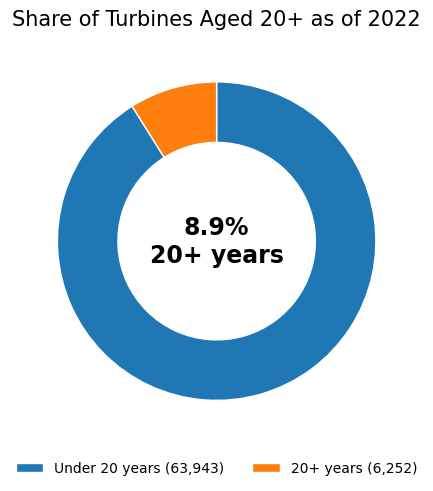

In [7]:
total_valid_age = valid_age["turbine_id"].nunique()
aging_count = aging["turbine_id"].nunique()
aging_pct = aging_count / total_valid_age * 100
under_20 = total_valid_age - aging_count

age_share = pd.DataFrame({
    "group": ["Under 20 years", "20+ years"],
    "turbines": [under_20, aging_count]
})
age_share["share_pct"] = age_share["turbines"] / age_share["turbines"].sum() * 100

display(age_share)

fig, ax = plt.subplots(figsize=(7, 5))
wedges, _ = ax.pie(
    age_share["turbines"],
    startangle=90,
    counterclock=False,
    wedgeprops={"width": 0.38, "edgecolor": "white"}
)
ax.text(
    0, 0,
    f"{aging_pct:.1f}%\n20+ years",
    ha="center",
    va="center",
    fontsize=17,
    fontweight="bold"
)
ax.set_title(f"Share of Turbines Aged 20+ as of {AS_OF_YEAR}", fontsize=15, pad=12)
ax.legend(
    wedges,
    [f"Under 20 years ({under_20:,})", f"20+ years ({aging_count:,})"],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)
plt.tight_layout()
plt.show()


## 5. Location of aging turbines

This section looks at the geographic distribution of turbines that were at least 20 years old in the 2022 inventory.


,state,aging_turbines,aging_rated_capacity_mw
1,CA,3417,432.92
17,TX,894,926.66
3,IA,507,381.01
13,OR,321,220.32
20,WA,307,226.30
7,MN,251,186.23
4,KS,170,112.20
23,WY,122,98.62
2,CO,77,61.35
22,WV,44,66.00


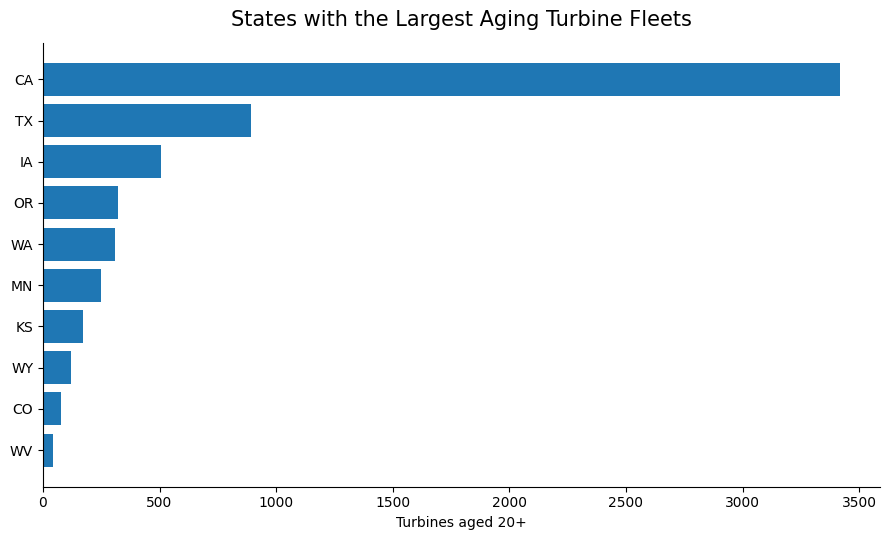

In [8]:
aging_by_state = (
    aging.groupby("state", as_index=False)
    .agg(
        aging_turbines=("turbine_id", "nunique"),
        aging_rated_capacity_mw=("turbine_capacity_kw", lambda s: s.sum(min_count=1)/1000)
    )
    .sort_values("aging_turbines", ascending=False)
)
display(aging_by_state.head(15))

fig, ax = plt.subplots(figsize=(9, 5.5))
top_states = aging_by_state.head(10).sort_values("aging_turbines")
ax.barh(top_states["state"], top_states["aging_turbines"])
ax.set_title(f"States with the Largest Aging Turbine Fleets", fontsize=15, pad=12)
ax.set_xlabel("Turbines aged 20+")
ax.set_ylabel("")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 6. Rated capacity over time

The cleaned turbine dataset contains project years through 2021. For that reason, the analysis uses the years available in the published data and does not extend the comparison beyond 2021.

Rated capacity is measured in MW and represents the turbine's nameplate capacity. It does not measure electricity generation, yield, reliability, capacity factor, or financial return.


,project_year,turbines,median_rated_capacity_mw
23,"2,007.00",3200,1.50
24,"2,008.00",5047,1.50
25,"2,009.00",5699,1.60
26,"2,010.00",2957,1.60
27,"2,011.00",3485,1.80
28,"2,012.00",6747,1.80
29,"2,013.00",585,1.70
30,"2,014.00",2498,1.85
31,"2,015.00",4280,2.00
32,"2,016.00",3762,2.00


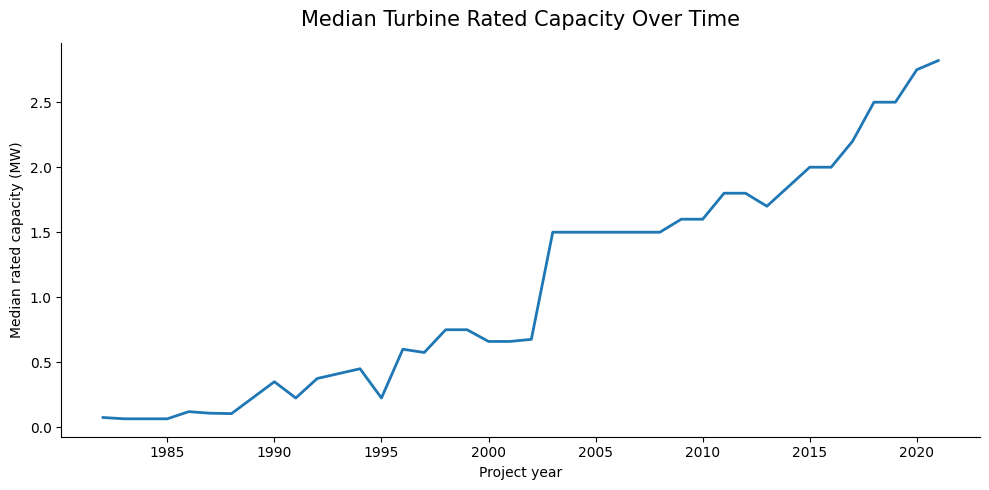

In [9]:
capacity_valid = wind.loc[
    wind["project_year"].notna() & wind["turbine_capacity_kw"].notna()
].copy()
capacity_valid["rated_capacity_mw"] = capacity_valid["turbine_capacity_kw"] / 1000

capacity_trend = (
    capacity_valid.groupby("project_year", as_index=False)
    .agg(
        turbines=("turbine_id", "nunique"),
        median_rated_capacity_mw=("rated_capacity_mw", "median")
    )
    .sort_values("project_year")
)

display(capacity_trend.tail(15))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(capacity_trend["project_year"], capacity_trend["median_rated_capacity_mw"], linewidth=2)
ax.set_title("Median Turbine Rated Capacity Over Time", fontsize=15, pad=12)
ax.set_xlabel("Project year")
ax.set_ylabel("Median rated capacity (MW)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


In [10]:
comparison = (
    capacity_valid.loc[capacity_valid["project_year"].isin(CAPACITY_COMPARE_YEARS)]
    .groupby("project_year", as_index=False)
    .agg(
        turbines=("turbine_id", "nunique"),
        median_rated_capacity_mw=("rated_capacity_mw", "median")
    )
    .sort_values("project_year")
)

old_year, new_year = CAPACITY_COMPARE_YEARS
old_median = comparison.loc[comparison["project_year"] == old_year, "median_rated_capacity_mw"].iloc[0]
new_median = comparison.loc[comparison["project_year"] == new_year, "median_rated_capacity_mw"].iloc[0]
pct_increase = (new_median - old_median) / old_median * 100

display(comparison)
print(f"Median rated capacity: {old_year} = {old_median:.2f} MW")
print(f"Median rated capacity: {new_year} = {new_median:.2f} MW")
print(f"Increase in median rated capacity = {pct_increase:.1f}%")

assert np.isclose(old_median, 1.80)
assert np.isclose(new_median, 2.82)
print("✓ Reproduced supported comparison: 1.80 MW → 2.82 MW, a 56.7% increase in median rated capacity.")

,project_year,turbines,median_rated_capacity_mw
0,"2,011.00",3485,1.80
1,"2,021.00",2209,2.82


Median rated capacity: 2011 = 1.80 MW
Median rated capacity: 2021 = 2.82 MW
Increase in median rated capacity = 56.7%
✓ Reproduced supported comparison: 1.80 MW → 2.82 MW, a 56.7% increase in median rated capacity.


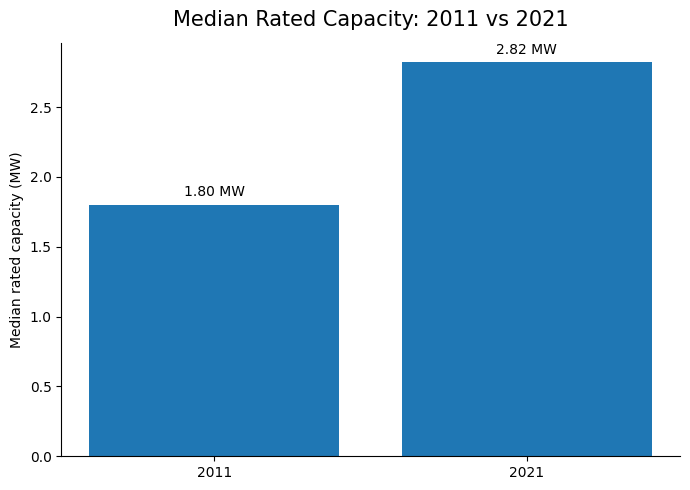

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(comparison["project_year"].astype(int).astype(str), comparison["median_rated_capacity_mw"])
ax.set_title(f"Median Rated Capacity: {old_year} vs {new_year}", fontsize=15, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Median rated capacity (MW)")
ax.spines[["top", "right"]].set_visible(False)

for bar, value in zip(bars, comparison["median_rated_capacity_mw"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.04,
        f"{value:.2f} MW",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


## 7. Operator matching

The EIA 923 dataset is joined to the turbine data using plant ID to attach the reported `Operator Name`. Turbines remain the unit of analysis, so each unique turbine is counted once.

The operator field identifies the reported operator in the EIA data and is not used as evidence of legal ownership.


In [12]:
# Check whether a plant maps to more than one operator name in this EIA extract.
operator_name_counts = eia.groupby("Plant Id")["Operator Name"].nunique(dropna=True)
print("Plants with >1 reported operator name:", int((operator_name_counts > 1).sum()))

# Build one operator record per plant. Duplicate EIA rows do not multiply turbine rows.
operator_lookup = (
    eia[["Plant Id", "Operator Id", "Operator Name"]]
    .dropna(subset=["Plant Id"])
    .drop_duplicates(subset=["Plant Id"])
)

aging_with_operator = aging.merge(
    operator_lookup,
    how="left",
    left_on="plant_id",
    right_on="Plant Id",
    validate="many_to_one"
)

assert aging_with_operator["turbine_id"].nunique() == aging["turbine_id"].nunique()
assert len(aging_with_operator) == len(aging)
print("✓ Join did not duplicate turbine rows.")

Plants with >1 reported operator name: 0
✓ Join did not duplicate turbine rows.


In [13]:
matched = aging_with_operator["Operator Name"].notna()
matched_turbines = aging_with_operator.loc[matched, "turbine_id"].nunique()
total_aging_turbines = aging_with_operator["turbine_id"].nunique()
operator_coverage_pct = matched_turbines / total_aging_turbines * 100

coverage = pd.DataFrame({
    "metric": ["Aging turbines", "Matched to reported operator", "Unmatched", "Operator match coverage"],
    "value": [
        f"{total_aging_turbines:,}",
        f"{matched_turbines:,}",
        f"{total_aging_turbines-matched_turbines:,}",
        f"{operator_coverage_pct:.1f}%"
    ]
})
display(coverage)

assert matched_turbines == 5040
print("✓ Operator match coverage = 80.6% (5,040 of 6,252 aging turbines).")

,metric,value
0,Aging turbines,"6,252"
1,Matched to reported operator,"5,040"
2,Unmatched,"1,212"
3,Operator match coverage,80.6%


✓ Operator match coverage = 80.6% (5,040 of 6,252 aging turbines).


### Operator screening

For the matched aging turbines, rated capacity is summed directly from individual turbine records. This avoids inflating totals through repeated project level turbine counts.


In [14]:
operator_summary = (
    aging_with_operator.loc[matched]
    .groupby("Operator Name", as_index=False)
    .agg(
        aging_turbines=("turbine_id", "nunique"),
        aging_rated_capacity_mw=("turbine_capacity_kw", lambda s: s.sum(min_count=1)/1000),
        median_age_years=("turbine_age", "median"),
        average_age_years=("turbine_age", "mean")
    )
    .sort_values(["aging_turbines", "aging_rated_capacity_mw"], ascending=False)
)

operator_summary["aging_rated_capacity_gw"] = operator_summary["aging_rated_capacity_mw"] / 1000
display(operator_summary.head(15))

,Operator Name,aging_turbines,aging_rated_capacity_mw,median_age_years,average_age_years,aging_rated_capacity_gw
48,Terra-Gen Operating Co-Wind,725,155.93,35.00,32.17,0.16
1,Allete Clean Energy,478,346.05,23.00,22.86,0.35
23,FPL Energy Vansycle LLC,454,299.64,21.00,20.87,0.30
6,Brookfield Renewable Trading and Marketing LP,433,28.78,39.00,38.96,0.03
9,CalWind Resources Inc,336,16.63,25.00,30.18,0.02
52,Wind Stream Operations LLC,234,1.89,40.00,39.73,0.00
22,FPL Energy Upton Wind LP,213,276.90,21.00,21.00,0.28
26,Gray County Wind Energy LLC,170,112.20,21.00,21.00,0.11
31,International Turbine Res Inc,162,17.01,34.00,34.00,0.02
46,Shell Wind Energy Inc.,152,151.42,20.00,20.32,0.15


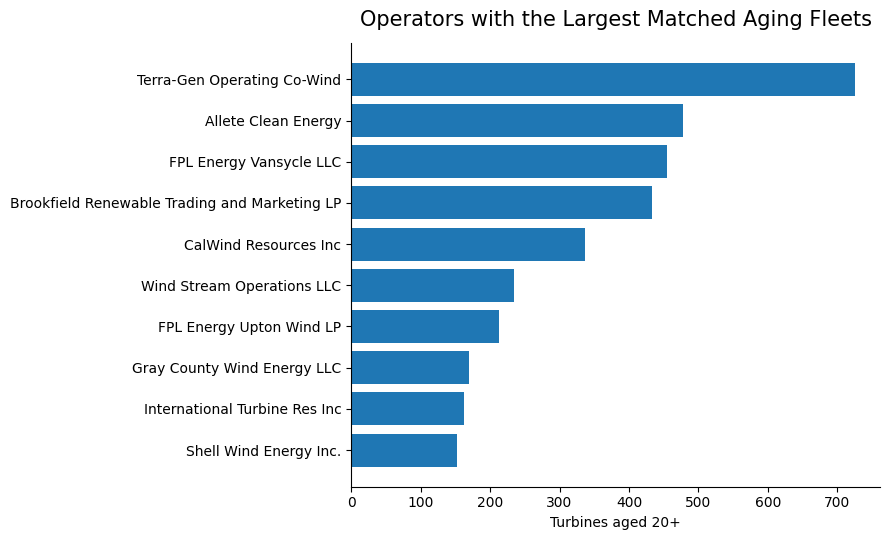

In [15]:
fig, ax = plt.subplots(figsize=(9, 5.5))
top_ops = operator_summary.head(10).sort_values("aging_turbines")
ax.barh(top_ops["Operator Name"], top_ops["aging_turbines"])
ax.set_title("Operators with the Largest Matched Aging Fleets", fontsize=15, pad=12)
ax.set_xlabel("Turbines aged 20+")
ax.set_ylabel("")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 8. Generation data

EIA 923 also includes annual net generation at the reporting or plant level. I keep this information separate from turbine rated capacity because the two measures answer different questions. A direct claim about energy yield would require a separate analysis with appropriately matched generation and asset data.


In [16]:
generation_summary = pd.DataFrame({
    "metric": ["EIA wind records", "Plants", "Total reported net generation (MWh)", "Records missing annual generation"],
    "value": [
        len(eia),
        eia["Plant Id"].nunique(),
        eia["Net Generation (Megawatthours)"].sum(min_count=1),
        eia["Net Generation (Megawatthours)"].isna().sum()
    ]
})
display(generation_summary)
print("No yield/reliability claim is derived from rated-capacity growth in this notebook.")

,metric,value
0,EIA wind records,"1,242.00"
1,Plants,"1,235.00"
2,Total reported net generation (MWh),"337,938,049.03"
3,Records missing annual generation,0.00


No yield/reliability claim is derived from rated-capacity growth in this notebook.


## 9. Result checks

The table below brings the main corrected results together in one place so they can be checked against the presentation and project documentation.


In [17]:
qa = pd.DataFrame([
    {
        "claim": "Fleet age reference",
        "reproducible_result": f"All turbine ages calculated as {AS_OF_YEAR} - project_year",
        "status": "PASS"
    },
    {
        "claim": f"Share aged {AGING_THRESHOLD}+",
        "reproducible_result": f"{aging['turbine_id'].nunique():,} / {valid_age['turbine_id'].nunique():,} = {aging['turbine_id'].nunique()/valid_age['turbine_id'].nunique()*100:.2f}%",
        "status": "PASS"
    },
    {
        "claim": "Published data supports 2024 capacity result",
        "reproducible_result": f"No — latest project year is {int(wind['project_year'].max())}",
        "status": "REMOVE OLD CLAIM"
    },
    {
        "claim": f"Median rated capacity {old_year} → {new_year}",
        "reproducible_result": f"{old_median:.2f} MW → {new_median:.2f} MW (+{pct_increase:.1f}%)",
        "status": "PASS"
    },
    {
        "claim": "Rated capacity equals yield",
        "reproducible_result": "No — rated capacity is nameplate power capability",
        "status": "DO NOT CLAIM"
    },
    {
        "claim": "Operator matching coverage for aging turbines",
        "reproducible_result": f"{matched_turbines:,} / {total_aging_turbines:,} = {operator_coverage_pct:.1f}%",
        "status": "PASS"
    },
    {
        "claim": "Operator = legal owner",
        "reproducible_result": "Not established by the supplied field",
        "status": "LABEL AS OPERATOR"
    }
])
display(qa)

,claim,reproducible_result,status
0,Fleet age reference,All turbine ages calculated as 2022 - project_...,PASS
1,Share aged 20+,"6,252 / 70,195 = 8.91%",PASS
2,Published data supports 2024 capacity result,No — latest project year is 2021,REMOVE OLD CLAIM
3,Median rated capacity 2011 → 2021,1.80 MW → 2.82 MW (+56.7%),PASS
4,Rated capacity equals yield,No — rated capacity is nameplate power capability,DO NOT CLAIM
5,Operator matching coverage for aging turbines,"5,040 / 6,252 = 80.6%",PASS
6,Operator = legal owner,Not established by the supplied field,LABEL AS OPERATOR


## 10. Key findings

Using 2022 as the reference year, 6,252 of the 70,195 turbines with a recorded project year were at least 20 years old. This represents 8.91% of the observed fleet with valid age information.

The turbine dataset supports capacity analysis through 2021. Median rated capacity increased from 1.80 MW for turbines in projects from 2011 to 2.82 MW for turbines in projects from 2021, an increase of 56.7% in nameplate capacity.

Of the 6,252 aging turbines, 5,040 were matched to a reported EIA operator through plant ID. This gives an operator match coverage of 80.6%. Operator results therefore describe the matched portion of the aging fleet rather than complete ownership of all assets.

Overall, the analysis identifies where older wind assets are concentrated and shows how turbine nameplate capacity has changed over time. These results can support an initial repowering market screen, while decisions about asset performance, ownership, operating costs, or investment return would require additional evidence.
